If running on HPC, select appropriate kernel: `big-data-dda-kernel`
<br>
If you couldn't find the kernel, it is likely that it is not installed, refer to the exercise notebook of DistributedComputing-I for more information.

In [1]:
%matplotlib inline

In [2]:
from matplotlib import pyplot as plt

# Initialisation of Spark environment
Tasks
- Initialialize spark cluster (only if running on HPC)
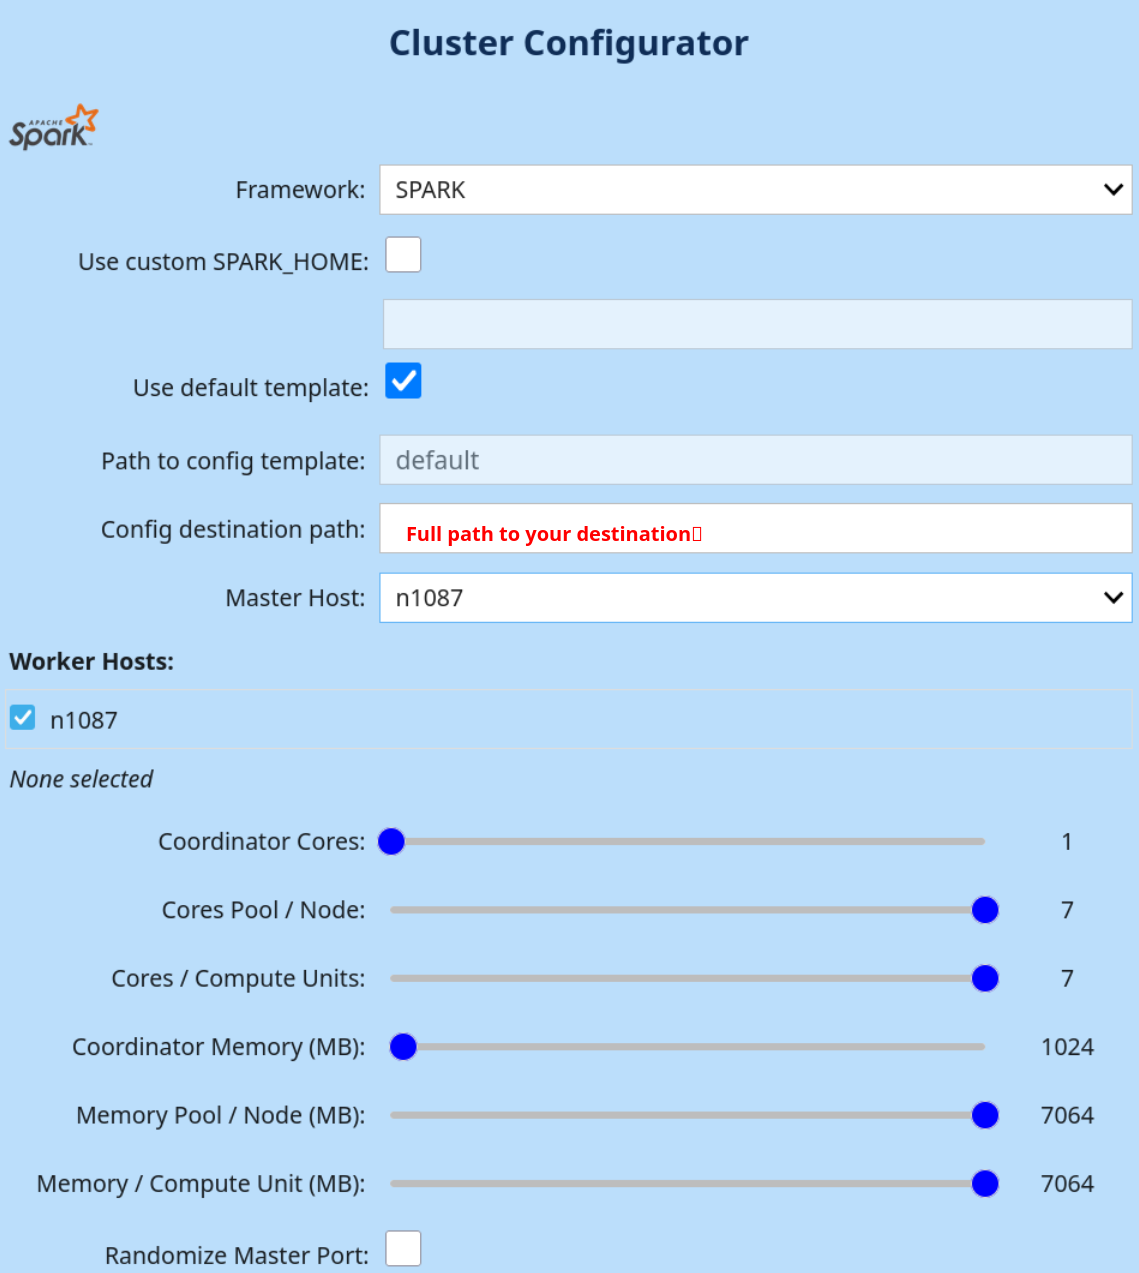

In [3]:
# Skip if running on local machine
# Set appropriate worker CPUs and Memory
# While initialiating spark context, do not forget to point it to the master node and port.

# import bijuty
!pip install findspark

## Initialize Spark Context
Task:
- Initialize spark context below

In [4]:
import platform
import pyspark
from pyspark.sql import SparkSession
import time
from random import random
from operator import add
import findspark
findspark.init()

In [5]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MonteCarloPi") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("INFO")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/13 12:07:31 WARN Utils: Your hostname, Krishnas-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.159 instead (on interface en0)
26/07/13 12:07:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/13 12:07:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Monte Carlo Estimation of π
To perform computation we will try to estimate value of Pi using Monte Carlo method. More information is available at this [link](https://www.selkie.macalester.edu/csinparallel/modules/CrossPlatformProgramming/build/html/MonteCarloPi/Pi.html).

![](http://www.physics.smu.edu/fattarus/pi.png)

Source code of the problem is used from [here](https://docs.cloudera.com/HDPDocuments/HDP2/HDP-2.3.0/bk_spark-quickstart/content/run_spark_pi.html).

# Exercise 1
Tasks
- 1.1: Measure time for map and reduce
- 1.2: Explain the results. Explain, why there is such huge time difference.

In [ ]:
def is_point_inside_unit_circle(p):
    x, y = random(), random()
    return 1 if x*x + y*y < 1 else 0

def functionToMeasure():
    total_darts = 10**7
    darts = sc.parallelize(range(0, total_darts))
    
    t0 = time.time()
    count = darts.map(is_point_inside_unit_circle)
    mapTime = time.time() - t0
    
    t1 = time.time()
    # Capture the count of darts inside the circle!
    darts_inside = count.reduce(add)
    reduceTime = time.time() - t1
    
    # Calculate Pi
    pi_val = darts_inside * 4 / total_darts
    
    return mapTime, reduceTime, pi_val

In [ ]:
mapTime, reduceTime, pi_val = functionToMeasure()

# Time map
print("Time map: " + str(mapTime))
# Time reduce
print("Time reduce: " + str(reduceTime))
# Print the Pi value
print("Pi value: " + str(pi_val))


Time map: 4.315376281738281e-05
Time reduce: 1.7980170249938965


**Explanation for Map vs Reduce Time:**
In Spark, `map` is a **Transformation** and `reduce` is an **Action**. Due to Spark's *lazy evaluation*, transformations are not executed immediately. Instead, Spark registers them in a Directed Acyclic Graph (DAG). When we measure the time for `map`, it only measures the time to build the DAG (which is nearly instantaneous). However, when `reduce` (an action) is called, the entire DAG is executed, which means both the data generation (`parallelize`), the `map` operation, and the actual `reduce` operation happen all at once. This explains why `reduceTime` is significantly larger than `mapTime`.

# Exercise 2
Tasks
- 2.1: Show the current Spark configuration.
- 2.2: Find a parameter to adjust the parallelism of Spark using spark session builder.
- 2.3: Stop the current Spark context and restart it with the parallelism set to 2 and appropriate master url.
- 2.4: Measure the computation time again.

In [8]:
print("Current Spark Configuration:")
for conf in sc.getConf().getAll():
    print(conf)

sc.stop()
spark.stop()

spark = SparkSession.builder \
    .master("local[2]") \
    .appName("MonteCarloPi_Parallelism_2") \
    .config("spark.default.parallelism", "2") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("INFO")

Current Spark Configuration:
('spark.rdd.compress', 'True')
('spark.hadoop.fs.s3a.vectored.read.min.seek.size', '128K')
('spark.sql.artifact.isolation.enabled', 'false')
('spark.executor.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add

In [9]:
mapTime, reduceTime = functionToMeasure()
# Time map
print("Time map: " + str(mapTime))
# Time reduce
print("Time reduce: " + str(reduceTime))

Time map: 1.7881393432617188e-05
Time reduce: 2.340751886367798


In [10]:
sc.stop()
spark.stop()

# Exercise 3a
Tasks
- 3a.1: Find a sweet spot for the parallelism
- 3a.2: Draw a graph of the computation time (x-axis: parallelism, y-axis: computation time)

In [11]:
duration = []
parallelismParameter = [*range(1,7)]

for p in parallelismParameter:
    spark = SparkSession.builder \
        .master(f"local[{p}]") \
        .appName(f"MonteCarloPi_{p}") \
        .config("spark.default.parallelism", str(p)) \
        .getOrCreate()
    sc = spark.sparkContext
    sc.setLogLevel("ERROR")
    
    mTime, rTime = functionToMeasure()
    total_time = mTime + rTime
    duration.append(total_time)
    
    sc.stop()
    spark.stop()

print(duration)
print(parallelismParameter)

[3.1964831352233887, 2.230186939239502, 1.7745578289031982, 1.6712369918823242, 1.528846025466919, 1.524933099746704]
[1, 2, 3, 4, 5, 6]


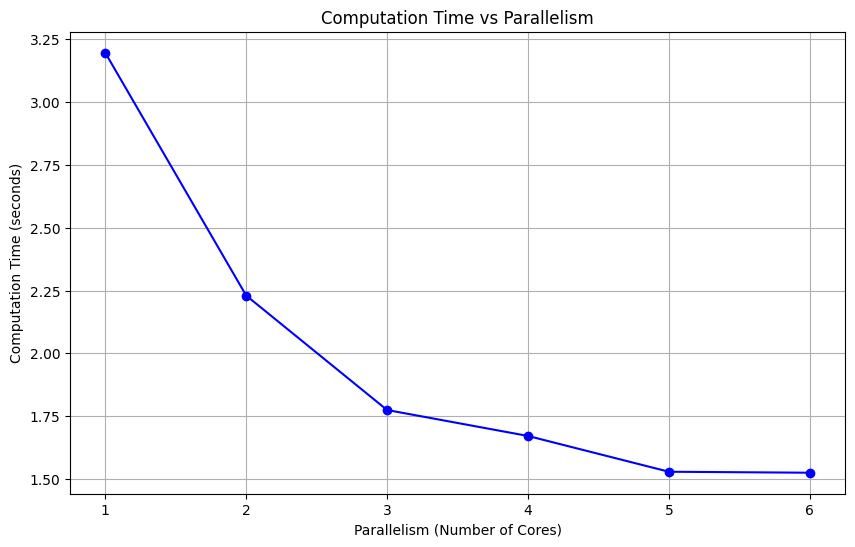

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(parallelismParameter, duration, marker='o', linestyle='-', color='b')
plt.title('Computation Time vs Parallelism')
plt.xlabel('Parallelism (Number of Cores)')
plt.ylabel('Computation Time (seconds)')
plt.grid(True)
plt.show()

In [13]:
pass # Spark context is stopped in the loop in the previous cell

# Exercise 3b
Tasks
- 3b.1: Now calculate the corresponding speed-up.
- 3b.2: Draw a graph of the speedup and discuss it. (x axis: parallelism, y axis: speedup)

Hint: You can find information about Amdahl's law and speedup [here](http://selkie.macalester.edu/csinparallel/modules/IntermediateIntroduction/build/html/ParallelSpeedup/ParallelSpeedup.html).

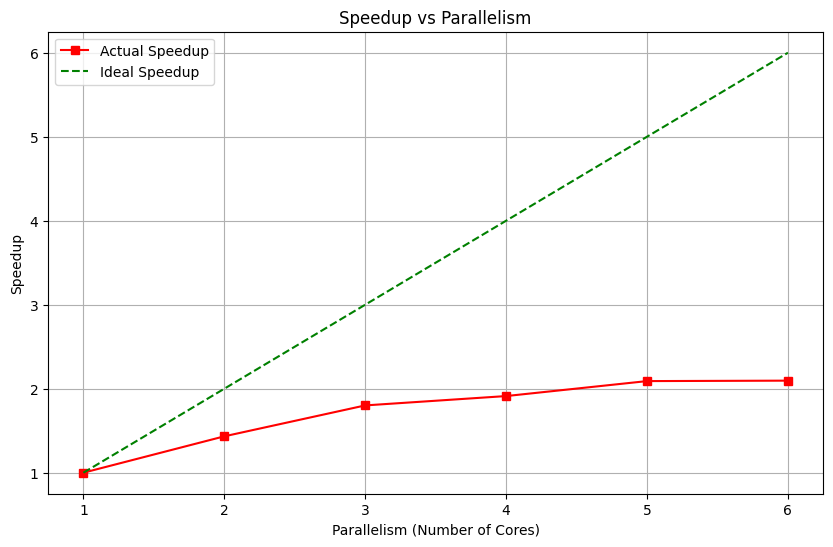

In [14]:
base_time = duration[0]
speedup = [base_time / t for t in duration]

plt.figure(figsize=(10, 6))
plt.plot(parallelismParameter, speedup, marker='s', linestyle='-', color='r', label='Actual Speedup')
plt.plot(parallelismParameter, parallelismParameter, linestyle='--', color='g', label='Ideal Speedup')
plt.title('Speedup vs Parallelism')
plt.xlabel('Parallelism (Number of Cores)')
plt.ylabel('Speedup')
plt.legend()
plt.grid(True)
plt.show()

# Exercise 4 - Only on HPC
In this exercise we will learn about scaleout (more than one node) of spark application on HPC cluster. Repeat the measurements on Barnard with multiple nodes and discuss the results. For this exercise we will use batch job to perform computation. More information about batch jobs can be found [here](https://compendium.hpc.tu-dresden.de/jobs_and_resources/slurm/#batch-jobs). This will also be demonstrated by instructors but students are encouraged to try on their own and present the results in the next exercise.

Tasks:
- Login to barnard cluster using `ssh`.
- copy the required files: `cp -r /projects/p_lv_dda_26/10-DistributedComputing-III $HOME/`
- Use `main.sh` script to run the multinode scalability investigations. To check how to use the script run `./main -h` in the terminal.
- Modify `app.py` as per the need.
- Find a way to submit a pyspark script (`app.py`) to the standalone cluster in `spark.sh` (lines 31-34,42-47, 52-54).
- Modify the `post_process.py` script for calculation of average processing time and speedup. Also add a logic to plot the results and save the figure.
- All the tasks are marked with `???` in the scripts.

Hint:
- Accessing HPC System using ssh: [Reference](https://compendium.hpc.tu-dresden.de/access/ssh_login/)
- You can try out different parameters for *--cpus-per-task* and *--nodes*
- The results are created in the output directory
- Submitting jobs to spark standalone cluster: [Reference](https://spark.apache.org/docs/3.5.0/spark-standalone.html)